In [16]:
# Describe properties, size, dimension, datatype, distribution of the dataset
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convert 'TotalCharges' to numeric, forcing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


print("Dataset Properties:")
print(f"Dataset shape: {df.shape}") # rows, columns
print(f"Dataset size: {df.size}") # Total number of elements
print(f"Dataset datatypes: {df.dtypes}") # Data types of each column
print(f"Dataset info: {df.info()}") # General information about the dataset
print(f"Dataset summary: {df.describe()}") # Summary statistics for numerical columns




Dataset Properties:
Dataset shape: (7043, 21)
Dataset size: 147903
Dataset datatypes: customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitize

In [21]:
null_count_name = df['TotalCharges'].isnull().sum()
print(f"Number of null values in 'TotalCharges' column: {null_count_name}")

#Drop rows with null values in 'TotalCharges' column
df = df.dropna(subset=['TotalCharges'])

# Check for missing values and duplicates

missing = df.isnull().sum().sum()
print(f"missing values: {missing}") # Total number of missing values

duplicaates = df.duplicated().sum()
print(f"duplicates: {duplicaates}") # Total number of duplicate rows

# Count of unique values per column
print(df.nunique())

# Display unique values for each column (optional)
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

# Save the cleaned dataset
df.to_csv('cleaned_telco_customer_churn.csv', index=False)

# Save the model using joblib
import joblib

model = "cleaned_telco_customer_churn.csv" # Replace with your actual model object"

joblib.dump(model, "model.pkl")



Number of null values in 'TotalCharges' column: 0
missing values: 0
duplicates: 22
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
Internet

['model.pkl']

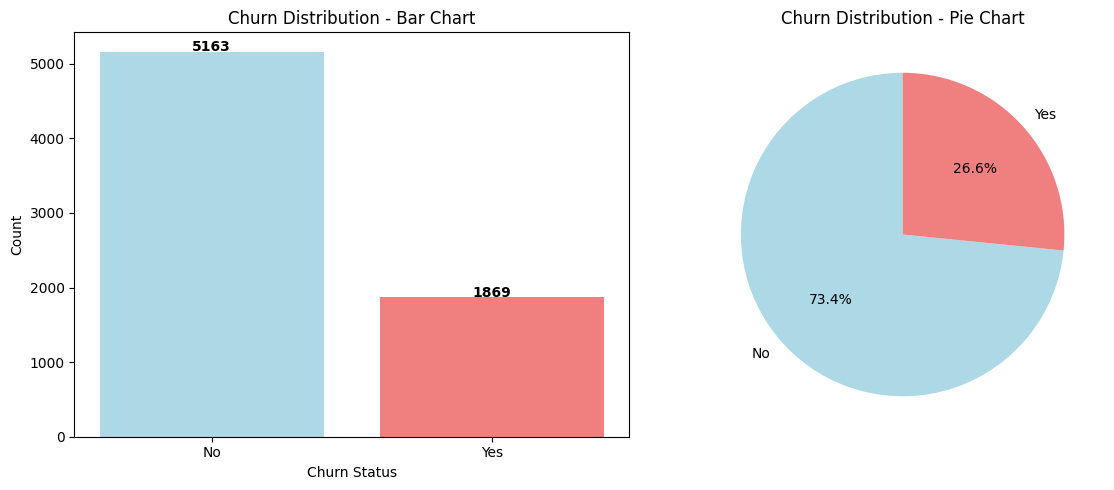

In [18]:
import matplotlib.pyplot as plt

counts= df.Churn.value_counts()



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(counts.index, counts.values, color=['lightblue', 'lightcoral'])
ax1.set_title('Churn Distribution - Bar Chart')
ax1.set_xlabel('Churn Status')
ax1.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')


ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%', 
        colors=['lightblue', 'lightcoral'], startangle=90)
ax2.set_title('Churn Distribution - Pie Chart')

plt.tight_layout()
plt.show()


In [19]:
df = df.drop(['customerID'], axis=1)
print(df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  